In [1]:
%matplotlib inline

from pysal.model import spreg
from pysal.lib import weights
#from pysal.explore import esda
from scipy import stats
import statsmodels.formula.api as sm
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sbn

import libpysal
from libpysal.weights import Queen
from sklearn.preprocessing import StandardScaler
import spreg


from pysal.lib import weights

/home/miguel/anaconda3/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.9.1-CAPI-1.14.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
gdf = gpd.read_file("../geoespacial_ageo/shapefile_basins/basins.shp")
gdf2 = gpd.read_file("/home/miguel/Documentos/Maestria_tesis/maestria_alejo/maestria_migue/materias/analisis_geoespacial/documentos_presentacion_2/segunda_entrega/shapefiles(1)/cuencas_bigonly")

In [3]:
gdf['tasa_exhum'].fillna(0, inplace=True)
gdf['Precipita'].fillna(0, inplace=True)
gdf['compresion'].fillna(0, inplace=True)
gdf['moho_depth'].fillna(0, inplace=True)

<AxesSubplot: >

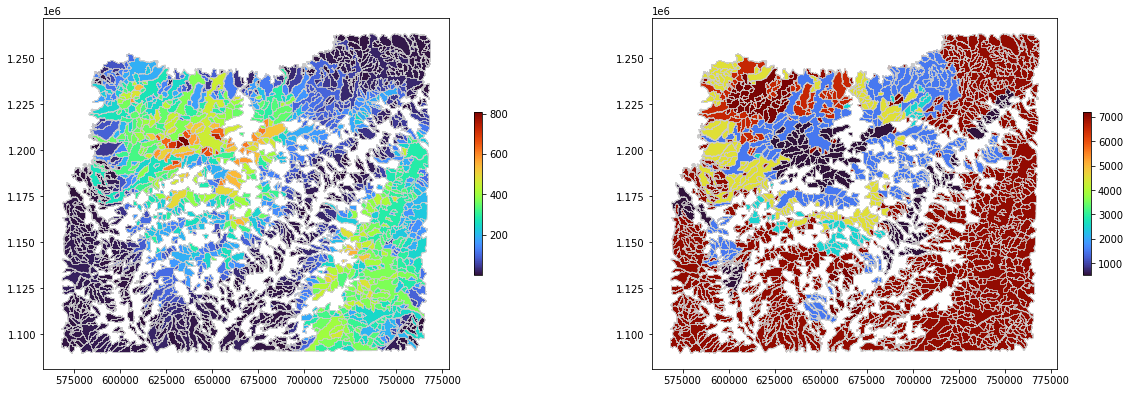

In [24]:
fig, axs = plt.subplots(1,2, figsize=(20,10))
gdf.plot(column='mean_ksn', cmap='turbo', linewidth=0.8, ax=axs[0], edgecolor='0.8',legend=True, legend_kwds={
        "shrink":.3})
gdf.plot(column='Precipita', cmap='turbo', linewidth=0.8, ax=axs[1], edgecolor='0.8',legend=True, legend_kwds={
        "shrink":.3})



<AxesSubplot: >

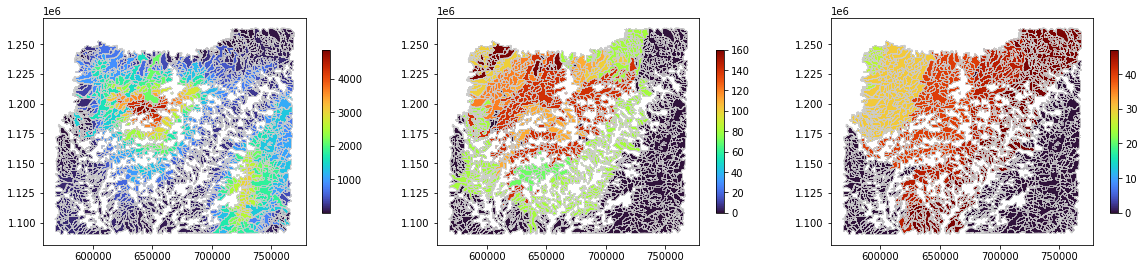

In [25]:
fig, axs = plt.subplots(1,3, figsize=(20,10))
gdf.plot(column='mean_el', cmap='turbo', linewidth=0.8, ax=axs[0], edgecolor='0.8',legend=True, legend_kwds={
        "shrink":.3})
gdf.plot(column='compresion', cmap='turbo', linewidth=0.8, ax=axs[1], edgecolor='0.8',legend=True, legend_kwds={
        "shrink":.3})
gdf.plot(column='moho_depth', cmap='turbo', linewidth=0.8, ax=axs[2], edgecolor='0.8',legend=True, legend_kwds={
        "shrink":.3})

In [8]:
y = gdf['tasa_exhum']
independent_vars = ['mean_ksn', 'Precipita', 'mean_el', 'compresion', 'moho_depth']
X = gdf[independent_vars].values

# Escalar las variables independientes
st = StandardScaler()
X_scaled = st.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=independent_vars)

# Crear la matriz de pesos espaciales por contiguidad tipo Quuen
w = Queen.from_dataframe(gdf)

# Calcular la autocorrelación exogena de las variables independientes escaladas
wx_dict = {}
for var in independent_vars:
    wx_dict[f'w_{var}'] = libpysal.weights.spatial_lag.lag_spatial(w, X_scaled_df[var])

wx_df = pd.DataFrame(wx_dict)

# Combinar las variables independientes originales escaladas con sus versiones espacialmente rezagadas
slx_exog = pd.concat([X_scaled_df, wx_df], axis=1)

# Ajustar el modelo OLS con las variable exógenas espacialmente rezagadas (SLX)
ols_model_slx = spreg.OLS(gdf['tasa_exhum'].values.reshape((-1,1)),
                          slx_exog.values,
                          name_y = 'tasa_exhum',
                          name_x=slx_exog.columns.tolist(),
                          name_w='queen_contiguity')

print(ols_model_slx.summary)

<ipython-input-8-56eb3e03a346>:11: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :  tasa_exhum                Number of Observations:        2997
Mean dependent var  :      0.0219                Number of Variables   :          11
S.D. dependent var  :      0.0545                Degrees of Freedom    :        2986
R-squared           :      0.4285
Adjusted R-squared  :      0.4266
Sum squared residual:     5.07772                F-statistic           :    223.8682
Sigma-square        :       0.002                Prob(F-statistic)     :           0
S.E. of regression  :       0.041                Log likelihood        :    5308.628
Sigma-square ML     :       0.002                Akaike info criterion :  -10595.255
S.E of regression ML:      0.0412                Schwarz criterion     :  -10529.196

------------------------------------------------------------

/home/miguel/anaconda3/lib/python3.8/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 60 disconnected components.
 There are 19 islands with ids: 482, 484, 1075, 1415, 1544, 1855, 1932, 2162, 2278, 2313, 2444, 2652, 2666, 2715, 2752, 2793, 2813, 2914, 2958.
  warnings.warn(message)


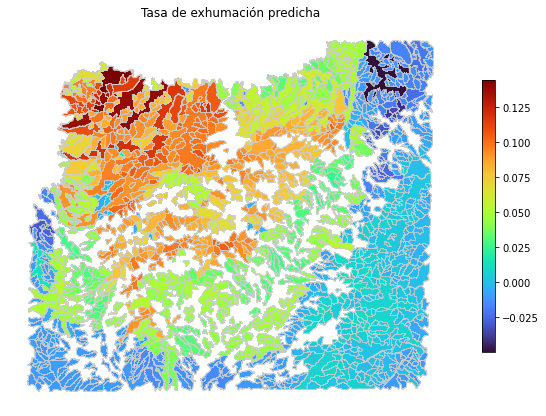

In [9]:
y_pred = ols_model_slx.predy

gdf['y_pred'] = y_pred

# Graficar el mapa con los valores de predicción
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='y_pred', cmap='turbo', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True, legend_kwds={
        "shrink":.5})

ax.set_title('Tasa de exhumación predicha')
ax.set_axis_off()
plt.show()

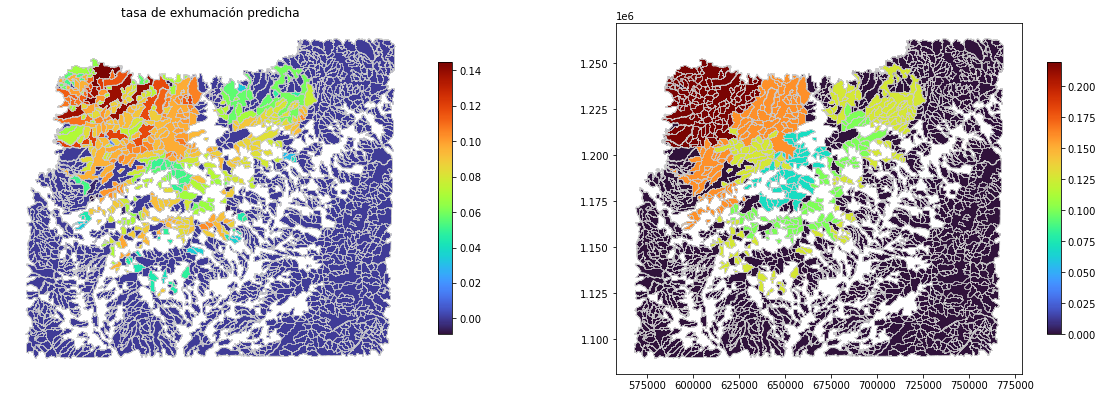

In [43]:
y_pred = ols_model_slx.predy

gdf['y_pred'] = y_pred

gdf['y_pred']=np.where(gdf['tasa_exhum'].eq(0), 0, gdf['y_pred'])

# Graficar el mapa con los valores de predicción
fig, axs = plt.subplots(1,2, figsize=(20,10))
gdf.plot(column='y_pred', cmap='turbo', linewidth=0.8, ax=axs[0], edgecolor='0.8', legend=True, legend_kwds={
        "shrink":.5})
gdf.plot(column='tasa_exhum', cmap='turbo', linewidth=0.8, ax=axs[1], edgecolor='0.8', legend=True, legend_kwds={
        "shrink":.5})

axs[0].set_title('tasa de exhumación predicha')
axs[0].set_axis_off()
plt.show()

In [31]:
# Calcular los residuos
residuals = gdf['tasa_exhum'] - y_pred[:,0]
# Añadir los residuales al dataframe
gdf['residuals'] = residuals

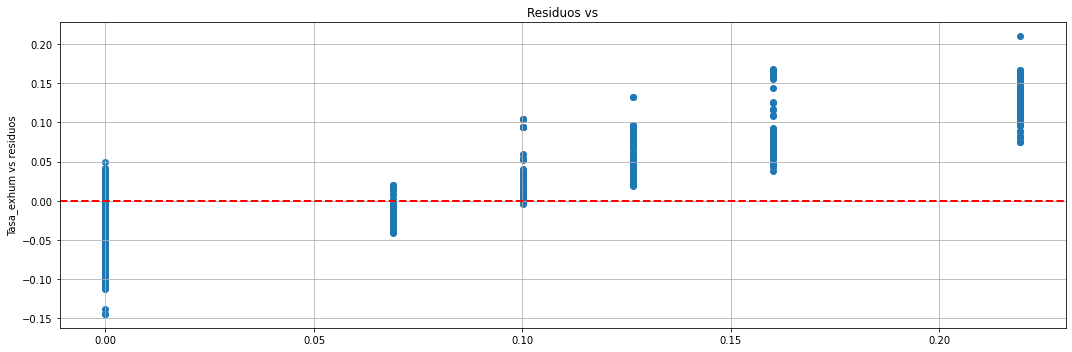

In [32]:


# Crear las figuras scatter para comparar los residuos con cada variable X
plt.figure(figsize=(15, 5))

#for i, variable in enumerate(var):
#    plt.subplot(1, 3, i + 1)
#    plt.scatter(gdf[variable], residuals)
#    plt.axhline(y=0, color='r', linestyle='--', lw=2)
#    plt.xlabel(variable)
#    plt.ylabel('Residuos')
#    plt.title(f'Residuos vs. {variable}')
#    plt.grid(True)
plt.scatter(gdf['tasa_exhum'], residuals)
plt.axhline(y=0, color='r', linestyle='--', lw=2)

plt.ylabel('Tasa_exhum vs residuos')
plt.title(f'Residuos vs')
plt.grid(True)    



plt.tight_layout()
plt.show()

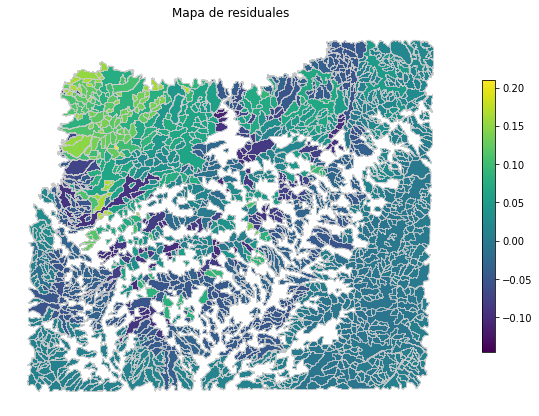

In [33]:
# Graficar el mapa con los valores de predicción
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='residuals', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True, legend_kwds={
        "shrink":.5})

ax.set_title('Mapa de residuales')
ax.set_axis_off()
plt.show()

In [34]:
from pysal.lib import weights
import esda

In [35]:
w = weights.Queen.from_dataframe(gdf, use_index=True)

/home/miguel/anaconda3/lib/python3.8/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 60 disconnected components.
 There are 19 islands with ids: 482, 484, 1075, 1415, 1544, 1855, 1932, 2162, 2278, 2313, 2444, 2652, 2666, 2715, 2752, 2793, 2813, 2914, 2958.
  warnings.warn(message)


In [36]:
mi = esda.Moran(gdf['residuals'], w)

('WARNING: ', 482, ' is an island (no neighbors)')
('WARNING: ', 484, ' is an island (no neighbors)')
('WARNING: ', 1075, ' is an island (no neighbors)')
('WARNING: ', 1415, ' is an island (no neighbors)')
('WARNING: ', 1544, ' is an island (no neighbors)')
('WARNING: ', 1855, ' is an island (no neighbors)')
('WARNING: ', 1932, ' is an island (no neighbors)')
('WARNING: ', 2162, ' is an island (no neighbors)')
('WARNING: ', 2278, ' is an island (no neighbors)')
('WARNING: ', 2313, ' is an island (no neighbors)')
('WARNING: ', 2444, ' is an island (no neighbors)')
('WARNING: ', 2652, ' is an island (no neighbors)')
('WARNING: ', 2666, ' is an island (no neighbors)')
('WARNING: ', 2715, ' is an island (no neighbors)')
('WARNING: ', 2752, ' is an island (no neighbors)')
('WARNING: ', 2793, ' is an island (no neighbors)')
('WARNING: ', 2813, ' is an island (no neighbors)')
('WARNING: ', 2914, ' is an island (no neighbors)')
('WARNING: ', 2958, ' is an island (no neighbors)')


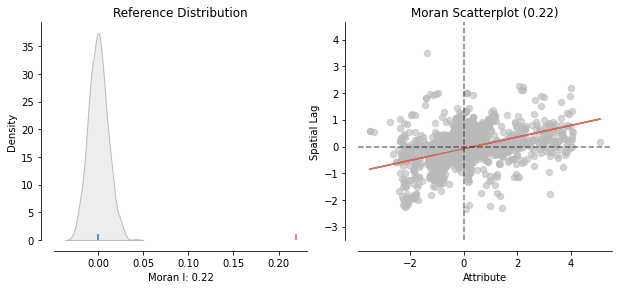

In [37]:
from pysal.viz import splot
from splot.esda import plot_moran
plot_moran(mi);

In [38]:
lisa = esda.Moran_Local(gdf['residuals'], w)

/home/miguel/anaconda3/lib/python3.8/site-packages/esda/moran.py:1059: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


In [39]:
# Break observation between significant or not
gdf['significant'] = lisa.p_sim < 0.05
#store the quadrant they belong to
gdf['quadrant'] = lisa.q

In [40]:
gdf['significant'].head()

0    False
1    False
2    False
3    False
4    False
Name: significant, dtype: bool

(<Figure size 432x288 with 1 Axes>, <AxesSubplot: >)

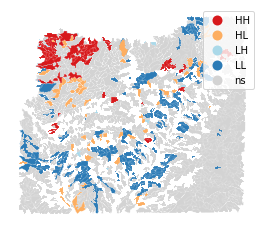

In [41]:
from splot.esda import lisa_cluster
lisa_cluster(lisa, gdf)

(<Figure size 1080x288 with 3 Axes>,
 array([<AxesSubplot: title={'center': 'Moran Local Scatterplot'}, xlabel='Attribute', ylabel='Spatial Lag'>,
        <AxesSubplot: >, <AxesSubplot: >], dtype=object))

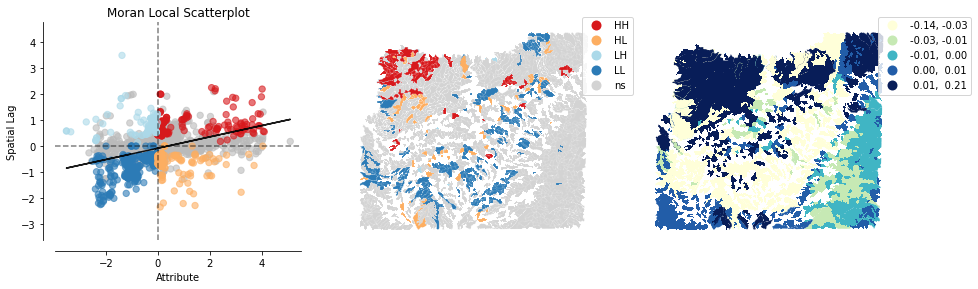

In [42]:
from splot.esda import plot_local_autocorrelation
plot_local_autocorrelation(lisa, gdf, 'residuals')